In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
config = {
    "sigma_pos": 10.0,
    "sigma_vel": 1.0,
    "sigma_init": 10.0,
    "e_v": 5.0,         
    "q": 1.0,          
    "N_particles": 15000
}

In [3]:
def generate_ground_truth(T=1000, dt=0.01):
    t = np.arange(0, T, dt)
    v0 = 50.0        # m/s
    ax = 0.2         # m/s^2
    A = 100.0        # amplitude lateral
    omega = 0.05     # rad/s

    x = v0*t + 0.5*ax*t**2
    y = A*np.sin(omega*t)

    vx = np.gradient(x,dt)
    vy = np.gradient(y,dt)

    return t, x, y, vx, vy

t, x, y, vx, vy = generate_ground_truth()

In [4]:
def radar_measurements(t_truth, x, y, sigma_pos, rate = 1.0):
    dt = 1 / rate
    t_radar = np.arange(0, t_truth[-1], dt)

    x_meas = np.interp(t_radar, t_truth, x)
    y_meas = np.interp(t_radar, t_truth, y)

    noise_pos = np.random.randn(len(t_radar), 2) * sigma_pos

    z_radar = np.column_stack((x_meas, y_meas)) + noise_pos

    return t_radar, z_radar

t_radar, z_radar = radar_measurements(t, x, y, config["sigma_pos"])

In [5]:
def imu_measurements(t_truth, vx, vy, sigma_vel, rate = 20.0):
    dt = 1 / rate
    t_imu = np.arange(0, t_truth[-1], dt)

    vx_meas = np.interp(t_imu, t_truth, vx)
    vy_meas = np.interp(t_imu, t_truth, vy)

    noise_vel = np.random.randn(len(t_imu), 2) * sigma_vel

    z_imu = np.column_stack((vx_meas, vy_meas)) + noise_vel

    return t_imu, z_imu

t_imu, z_imu = imu_measurements(t, vx, vy, config["sigma_vel"])

In [6]:
radar_available = np.zeros(len(t_imu), dtype = bool)
radar_available[::20] = True

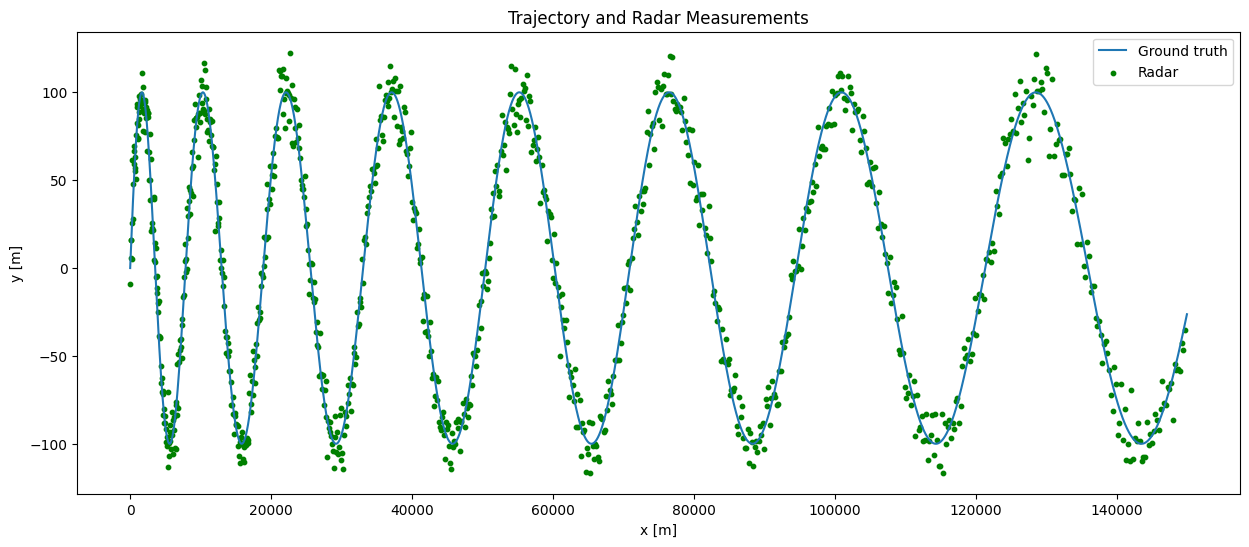

In [7]:
plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_radar[:,0], z_radar[:,1], s = 10, label = "Radar", color = "green")
plt.legend()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajectory and Radar Measurements")
plt.show()

In [8]:
def init_kalman(z_radar, z_imu, config):

    sigma_pos = config["sigma_pos"]
    sigma_vel = config["sigma_vel"]
    
    x0 = np.array([z_radar[0, 0], z_radar[0, 1], z_imu[0, 0], z_imu[0, 1]]).reshape(4, 1)
    P0 = np.diag([sigma_pos**2, sigma_pos**2, sigma_vel**2, sigma_vel**2]) * 10
    
    H_pos = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    H_vel = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    
    R_pos = np.eye(2) * sigma_pos**2
    R_vel = np.eye(2) * sigma_vel**2

    return x0, P0, H_pos, H_vel, R_pos, R_vel

In [9]:
def run_kalman_filter(t_radar, t_imu, z_radar, z_imu, radar_available, x_hat, P, H_pos, H_vel, R_pos, R_vel, q) :

    x_estimates = []
    x_estimates.append(x_hat.copy())

    radar_idx = 0
    
    for k in range(1, len(t_imu)) :
    
        dt = t_imu[k] - t_imu[k-1]
    
        F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        
        Q = q * np.array([
            [dt**4/4, 0, dt**3/2, 0],
            [0, dt**4/4, 0, dt**3/2],
            [dt**3/2, 0, dt**2, 0],
            [0, dt**3/2, 0, dt**2]
        ])
    
        x_hat = F @ x_hat
        P = F @ P @ F.T + Q
    
        z_vel = z_imu[k].reshape(2,1)
        y = z_vel - H_vel @ x_hat
        S = H_vel @ P @ H_vel.T + R_vel
        K = P @ H_vel.T @ np.linalg.inv(S)
        x_hat = x_hat + K @ y
        P = (np.eye(4) - K @ H_vel) @ P

        if radar_available[k] :
            z_pos = z_radar[radar_idx].reshape((2,1))
            y = z_pos - H_pos @ x_hat
            S = H_pos @ P @ H_pos.T + R_pos
            K = P @ H_pos.T @ np.linalg.inv(S)
            x_hat = x_hat + K @ y
            P = (np.eye(4) - K @ H_pos) @ P

            radar_idx +=1
            
        x_estimates.append(x_hat.copy())
    return np.array(x_estimates)

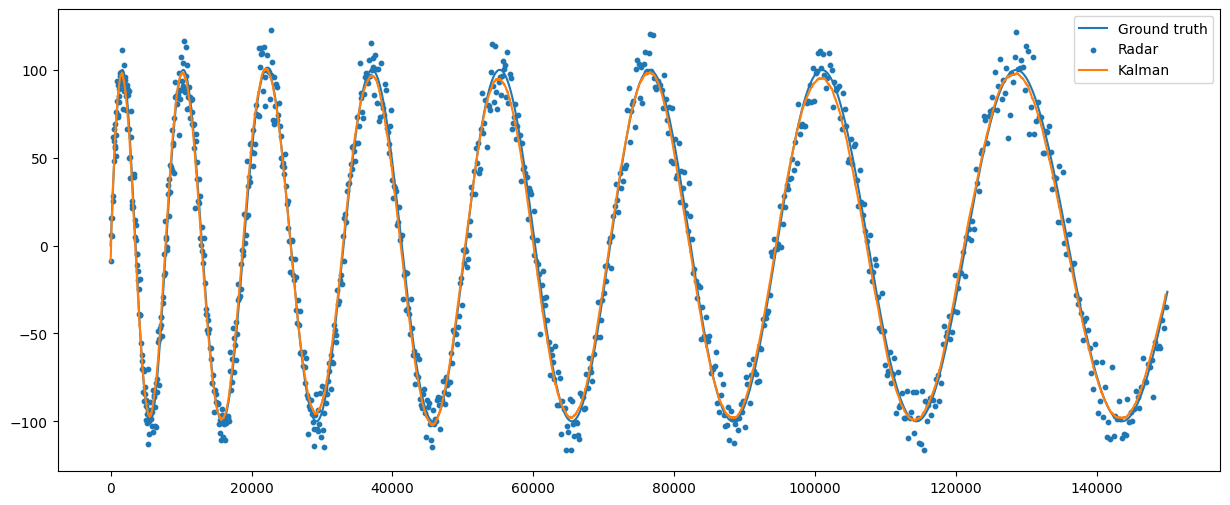

In [10]:
x0, P0, H_pos, H_vel, R_pos, R_vel = init_kalman(z_radar, z_imu, config)
x_kalman = run_kalman_filter(t_radar, t_imu, z_radar, z_imu, radar_available, x0, P0, H_pos, H_vel, R_pos, R_vel, config["q"]).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_radar[:,0], z_radar[:,1], s= 10, label = "Radar")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "Kalman")
plt.legend()
plt.show()

In [11]:
def init_particles(z_radar, z_imu, config):
    
    N = config["N_particles"]
    e_v = config["e_v"]
    sigma_init = config["sigma_init"]
    
    particles = np.zeros((N, 4))
    
    particles[:, 0] = z_radar[0, 0] + np.random.randn(N) * sigma_init
    particles[:, 1] = z_radar[0, 1] + np.random.randn(N) * sigma_init
    particles[:, 2] = z_imu[0, 0] + np.random.randn(N) * e_v
    particles[:, 3] = z_imu[0, 1] + np.random.randn(N) * e_v
    
    weights = np.ones(N) / N

    return particles, weights

In [12]:
def predict_particles(particles, dt, q) :
    N = particles.shape[0]

    noise_pos = np.random.randn(N, 2) * np.sqrt(q) * dt**2 / 2
    noise_vel = np.random.randn(N, 2) * np.sqrt(q) * dt

    particles[:, 0] += particles[:, 2] * dt + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + noise_pos[:, 1]
    particles[:, 2] += noise_vel[:, 0]
    particles[:, 3] += noise_vel[:, 1]

    return particles

In [13]:
def update_weights_position(particles, weights, z_pos, sigma_pos) :
    diffs = particles[:, :2] - z_pos.reshape(1, 2)
    
    d2_pos = np.sum(diffs**2, axis = 1)

    log_w = -0.5 * (d2_pos / sigma_pos**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [14]:
def update_weights_velocity(particles, weights, z_vel, sigma_vel) :
    diffs = particles[:, 2:] - z_vel.reshape(1, 2)
    
    d2_vel = np.sum(diffs**2, axis = 1)

    log_w = -0.5 * (d2_vel / sigma_vel**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [15]:
def N_eff(weights) :
    return 1. / np.sum(weights**2)

In [16]:
def resample(particles, weights) :
    N = len(weights)
    positions = (np.arange(N) + np.random.rand()) / N

    indexes = np.zeros(N, dtype = int)
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0

    while i < N :
        if positions[i] < cumulative_sum[j] :
            indexes[i] = j
            i += 1  
        else :
            j += 1

    particles[:] = particles[indexes]
    weights.fill(1 / N)

    return particles, weights

In [17]:
def estimate(particles, weights) :
    return np.average(particles, weights = weights, axis = 0)

In [18]:
def run_particle_filter(t_radar, t_imu, z_radar, z_imu, radar_available, particles, weights, q, sigma_pos, sigma_vel) :

    estimates = []
    x_est0 = np.average(particles, weights=weights, axis=0)
    estimates.append(x_est0.copy())

    radar_idx = 0
    
    for k in range(1, len(t_imu)) :
        dt = t_imu[k] - t_imu[k-1]
    
        particles = predict_particles(particles, dt, q)
    
        if not np.isnan(z_imu.any()) :
            weights = update_weights_velocity(particles, weights, z_imu[k], config["sigma_vel"])

        if radar_available[k] :
            weights = update_weights_position(particles, weights, z_radar[radar_idx], config["sigma_pos"])
            radar_idx += 1
                
        if N_eff(weights) < config["N_particles"] * 0.5 :
            particles, weights = resample(particles, weights)
    
        x_hat = estimate(particles, weights)
        estimates.append(x_hat.copy())
    return np.array(estimates)

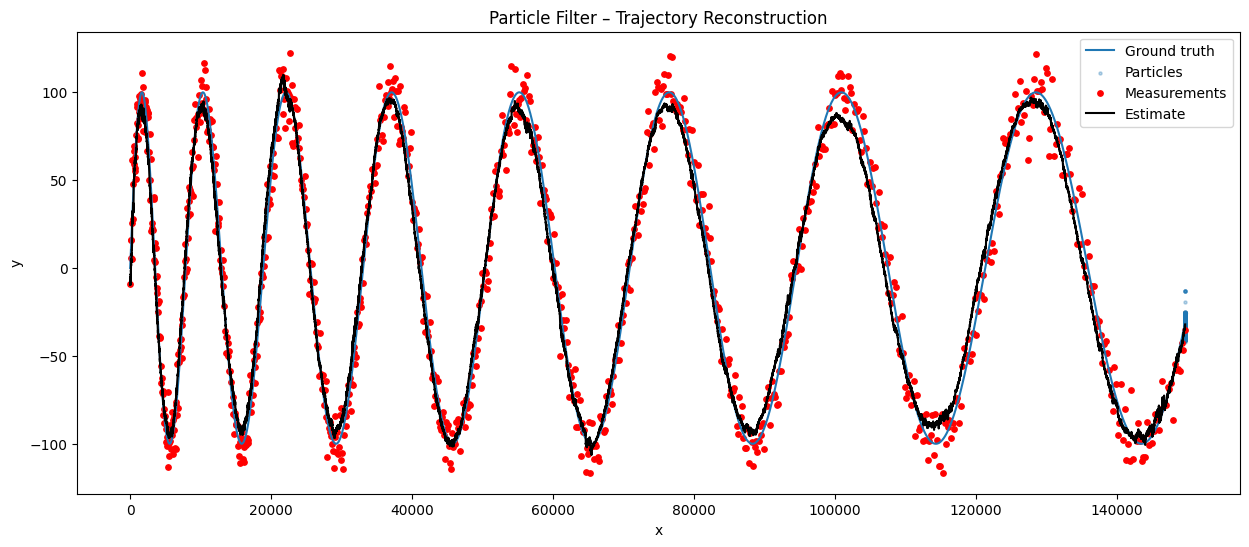

In [19]:
particles, weights = init_particles(z_radar, z_imu, config)
x_pf = run_particle_filter(t_radar, t_imu, z_radar, z_imu, radar_available, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_radar[:, 0], z_radar[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()

In [20]:
def rms_position(x_est, x_true) :
    error_pos = x_est[:, :2] - x_true[:, :2]
    return np.sqrt(np.mean(np.sum(error_pos**2, axis = 1)))

In [21]:
def rms_velocity( x_est, x_true) :
    error_vel = x_est[:, 2:] - x_true[:, 2:]
    return np.sqrt(np.mean(np.sum(error_vel**2, axis = 1)))

In [22]:
x_true = np.column_stack((
    np.interp(t_imu, t, x),
    np.interp(t_imu, t, y),
    np.interp(t_imu, t, vx),
    np.interp(t_imu, t, vy)
))

In [23]:
rms_kalman_pos = rms_position(x_kalman, x_true)
rms_pf_pos = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_pos)
print("RMS Particle Filter: ", rms_pf_pos)

RMS Kalman:  151.71000684970303
RMS Particle Filter:  142.64829485485714


In [24]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  0.3373432689279004
RMS Particle Filter:  0.5358401610601127


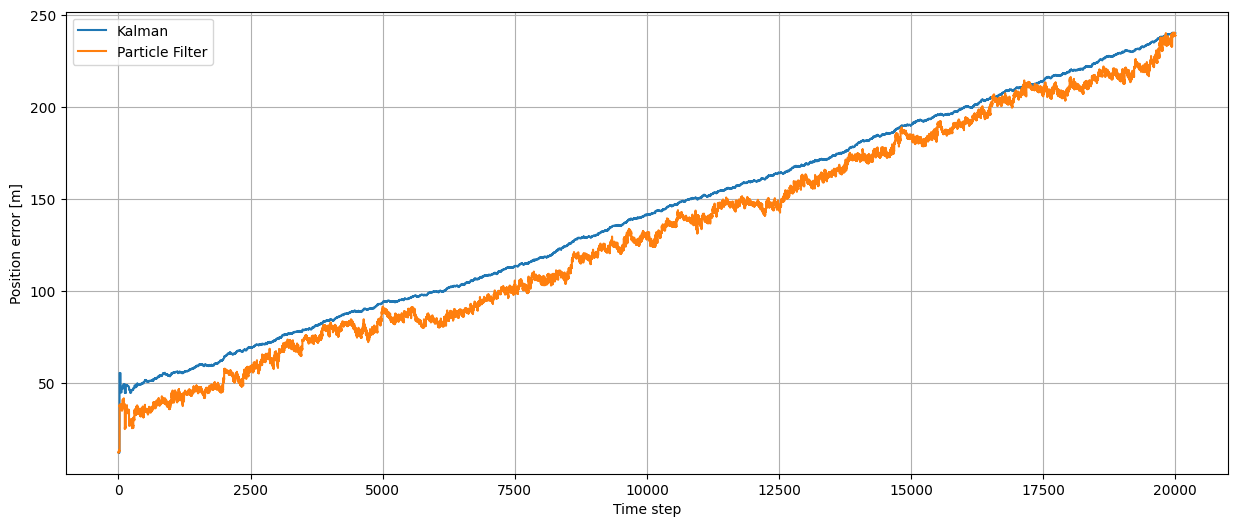

In [25]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [26]:
def radar_measurements_outliers(t_truth, x, y, sigma_pos, rate = 1, p_outlier = 0.1, outlier_scale_p = 10):
    dt_meas = 1/rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)

    noise_pos = np.random.randn(len(t_meas), 2) * sigma_pos

    outliers = np.random.rand(len(t_meas)) < p_outlier
    noise_pos[outliers] += np.random.randn(np.sum(outliers), 2) * sigma_pos * outlier_scale_p
    
    z = np.column_stack((x_meas, y_meas)) + noise_pos
    return t_meas, z

t_radar, z_radar = radar_measurements_outliers(t, x, y, config["sigma_pos"])

In [27]:
def imu_measurements_outliers(t_truth, vx, vy, sigma_vel, rate = 20, p_outlier = 0.05, outlier_scale_v = 3):
    dt_meas = 1/rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    vx_meas = np.interp(t_meas, t_truth, vx)
    vy_meas = np.interp(t_meas, t_truth, vy)

    noise_vel = np.random.randn(len(t_meas), 2) * sigma_vel

    outliers = np.random.rand(len(t_meas)) < p_outlier
    noise_vel[outliers] += np.random.randn(np.sum(outliers), 2) * sigma_vel * outlier_scale_v
    
    z = np.column_stack((vx_meas, vy_meas)) + noise_vel
    return t_meas, z

t_imu, z_imu = imu_measurements_outliers(t, vx, vy, config["sigma_vel"])

In [28]:
x0, P0, H_pos, H_vel, R_pos, R_vel = init_kalman(z_radar, z_imu, config)
x_kalman = run_kalman_filter(t_radar, t_imu, z_radar, z_imu, radar_available, x0, P0, H_pos, H_vel, R_pos, R_vel, config["q"]).squeeze()

particles, weights = init_particles(z_radar, z_imu, config)
x_pf = run_particle_filter(t_radar, t_imu, z_radar, z_imu, radar_available, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

In [29]:
rms_kalman = rms_position(x_kalman, x_true)
rms_pf = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman)
print("RMS Particle Filter: ", rms_pf)

RMS Kalman:  154.36315163080263
RMS Particle Filter:  137.1814278357639


In [30]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  0.37112879223394385
RMS Particle Filter:  0.7226443495978633


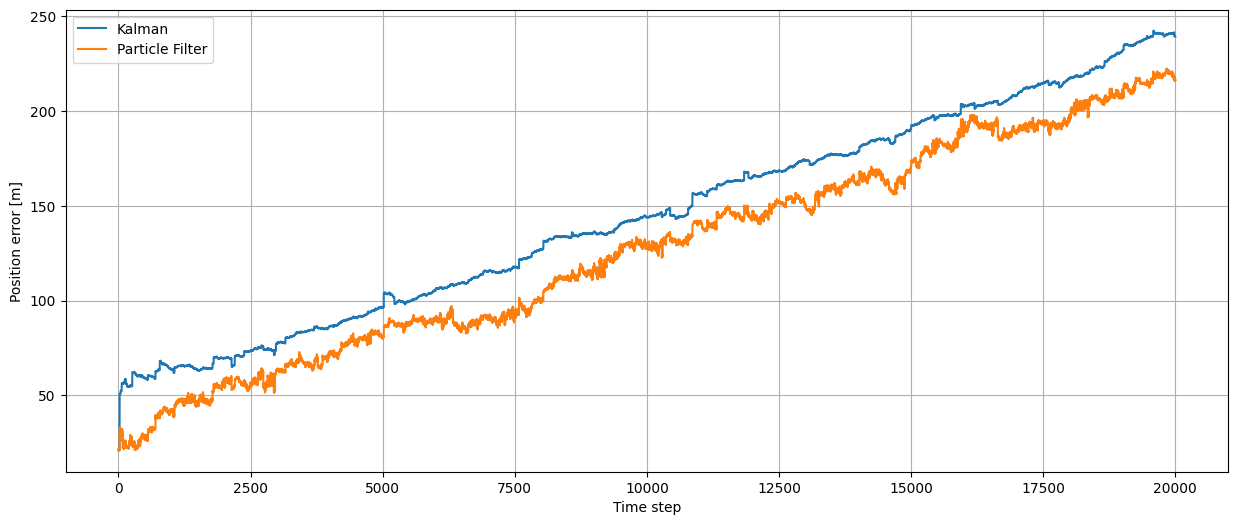

In [31]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()